# DATATHON 2026 - Optimized Time-Series Notebook (V2)

This is a separate notebook from existing pipelines, focused on improving leaderboard score with strict anti-leakage forecasting.

## Internet-backed references used

- scikit-learn TimeSeriesSplit documentation:
  - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- scikit-learn lagged-feature forecasting example:
  - https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html
- LightGBM Python API (callbacks and early stopping):
  - https://lightgbm.readthedocs.io/en/latest/Python-API.html
- XGBoost sklearn API (early stopping behavior):
  - https://xgboost.readthedocs.io/en/stable/python/python_api.html
- FPP3 rolling-origin cross-validation notes:
  - https://otexts.com/fpp3/tscv.html

## Strategy in this notebook

1. Strict temporal split (train to 2021, validation 2022, test from sample submission).
2. Lag/rolling features with recursive multi-step forecasting to reduce train-test mismatch.
3. Use master_table in a leakage-safe way via historical seasonal priors.
4. Blend LightGBM + XGBoost and tune blend/seasonal weight on validation.
5. Calibrate and enforce Revenue/COGS coherence before saving submission.


In [1]:
%pip install -q numpy pandas scikit-learn lightgbm xgboost catboost optuna matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import lightgbm as lgb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [3]:
ROOT = Path(".").resolve()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "output"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sales = pd.read_csv(RAW_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date")
sample_submission = pd.read_csv(RAW_DIR / "sample_submission.csv", parse_dates=["Date"]).sort_values("Date")

master_usecols = [
    "order_date",
    "order_id",
    "order_item_id",
    "customer_id",
    "quantity",
    "unit_price",
    "discount_amount",
    "line_revenue",
    "line_cogs",
    "promo_id",
    "review_id",
    "return_quantity",
]

master = pd.read_csv(
    OUT_DIR / "master_table.csv",
    usecols=master_usecols,
    parse_dates=["order_date"],
    low_memory=False,
)

print("ROOT:", ROOT)
print("sales shape:", sales.shape)
print("sample_submission shape:", sample_submission.shape)
print("master subset shape:", master.shape)

sales.head()

ROOT: D:\DATATHON-2026-GenApLucUWU
sales shape: (3833, 3)
sample_submission shape: (548, 3)
master subset shape: (714669, 12)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [4]:
TRAIN_END = pd.Timestamp("2021-12-31")
VAL_START = pd.Timestamp("2022-01-01")
VAL_END = pd.Timestamp("2022-12-31")
TEST_START = sample_submission["Date"].min()
TEST_END = sample_submission["Date"].max()

print("Train window:", sales["Date"].min().date(), "->", TRAIN_END.date())
print("Validation window:", VAL_START.date(), "->", VAL_END.date())
print("Test window:", TEST_START.date(), "->", TEST_END.date())

assert {"Date", "Revenue", "COGS"}.issubset(sample_submission.columns)
assert sales["Date"].is_monotonic_increasing
assert sample_submission["Date"].is_monotonic_increasing

sales_full = sales.set_index("Date").asfreq("D")
if sales_full[["Revenue", "COGS"]].isna().any().any():
    sales_full[["Revenue", "COGS"]] = sales_full[["Revenue", "COGS"]].interpolate(method="time").ffill().bfill()

print("Missing values after asfreq:")
print(sales_full[["Revenue", "COGS"]].isna().sum())

sales_full.head()

Train window: 2012-07-04 -> 2021-12-31
Validation window: 2022-01-01 -> 2022-12-31
Test window: 2023-01-01 -> 2024-07-01
Missing values after asfreq:
Revenue    0
COGS       0
dtype: int64


,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79


In [5]:
for col in ["quantity", "unit_price", "discount_amount", "line_revenue", "line_cogs", "return_quantity"]:
    master[col] = pd.to_numeric(master[col], errors="coerce").fillna(0.0)

master["has_promo"] = (~master["promo_id"].astype(str).str.lower().isin(["none", "0", "nan"])).astype(int)
master["has_review"] = (~master["review_id"].astype(str).str.lower().isin(["none", "0", "nan"])).astype(int)

daily_master = (
    master.groupby("order_date", as_index=False)
    .agg(
        mt_order_items=("order_item_id", "count"),
        mt_orders=("order_id", "nunique"),
        mt_customers=("customer_id", "nunique"),
        mt_qty=("quantity", "sum"),
        mt_unit_price_mean=("unit_price", "mean"),
        mt_discount_sum=("discount_amount", "sum"),
        mt_line_revenue_sum=("line_revenue", "sum"),
        mt_line_cogs_sum=("line_cogs", "sum"),
        mt_has_promo_rate=("has_promo", "mean"),
        mt_has_review_rate=("has_review", "mean"),
        mt_return_qty_sum=("return_quantity", "sum"),
    )
    .sort_values("order_date")
)

daily_master.head()

,order_date,mt_order_items,mt_orders,mt_customers,mt_qty,mt_unit_price_mean,mt_discount_sum,mt_line_revenue_sum,mt_line_cogs_sum,mt_has_promo_rate,mt_has_review_rate,mt_return_qty_sum
0,2012-07-04,174,162,161,777,6394.123563,0.0,5123547.94,3.982991e+06,1.0,1.0,26.0
1,2012-07-05,103,97,97,428,6744.283107,0.0,2751773.45,2.150580e+06,1.0,1.0,15.0
2,2012-07-06,99,93,93,441,6793.819596,0.0,3054029.42,2.517633e+06,1.0,1.0,28.0
3,2012-07-07,75,73,73,364,7475.478533,0.0,2667930.94,2.108247e+06,1.0,1.0,14.0
4,2012-07-08,94,88,87,394,5766.682021,0.0,2360851.90,1.808623e+06,1.0,1.0,21.0


In [6]:
LAGS = [1, 2, 3, 7, 14, 21, 28, 35, 42, 56, 84, 112, 168, 364]
ROLL_WINDOWS = [7, 14, 28, 56, 84, 112, 168]
EXP_WINDOWS = [7, 28, 84]


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    frac = np.where(denom == 0, 0.0, 2.0 * np.abs(y_true - y_pred) / denom)
    return float(np.mean(frac) * 100.0)


def metric_table(name, y_true, y_pred):
    return pd.DataFrame(
        [
            {
                "model": name,
                "MAE": mean_absolute_error(y_true, y_pred),
                "RMSE": rmse(y_true, y_pred),
                "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100.0,
                "SMAPE": smape(y_true, y_pred),
            }
        ]
    )


def build_master_priors(cutoff_date):
    hist = daily_master[daily_master["order_date"] <= cutoff_date].copy()
    hist["dow"] = hist["order_date"].dt.dayofweek
    hist["month"] = hist["order_date"].dt.month

    mt_cols = [c for c in hist.columns if c.startswith("mt_")]
    dow_prior = hist.groupby("dow")[mt_cols].mean()
    month_prior = hist.groupby("month")[mt_cols].mean()
    global_prior = hist[mt_cols].mean()

    return dow_prior, month_prior, global_prior

In [7]:
def build_target_priors(series, cutoff_date):
    hist = series.loc[:cutoff_date]
    dow_prior = hist.groupby(hist.index.dayofweek).mean().to_dict()
    month_prior = hist.groupby(hist.index.month).mean().to_dict()
    global_prior = float(hist.mean())
    return dow_prior, month_prior, global_prior


def add_calendar_features(df):
    idx = df.index
    day_of_year = idx.dayofyear

    df["dow"] = idx.dayofweek
    df["dom"] = idx.day
    df["month"] = idx.month
    df["quarter"] = idx.quarter
    df["weekofyear"] = idx.isocalendar().week.astype(int)
    df["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    df["is_month_start"] = idx.is_month_start.astype(int)
    df["is_month_end"] = idx.is_month_end.astype(int)

    df["sin_doy"] = np.sin(2.0 * np.pi * day_of_year / 365.25)
    df["cos_doy"] = np.cos(2.0 * np.pi * day_of_year / 365.25)
    df["sin_dow"] = np.sin(2.0 * np.pi * idx.dayofweek / 7.0)
    df["cos_dow"] = np.cos(2.0 * np.pi * idx.dayofweek / 7.0)

    return df


def build_training_frame(series, cutoff_date, master_dow, master_month, master_global):
    target_dow, target_month, target_global = build_target_priors(series, cutoff_date)

    df = pd.DataFrame(index=series.index)
    df["y"] = series.values

    for lag in LAGS:
        df[f"lag_{lag}"] = series.shift(lag)

    shifted = series.shift(1)
    for w in ROLL_WINDOWS:
        df[f"roll_mean_{w}"] = shifted.rolling(w).mean()
        df[f"roll_std_{w}"] = shifted.rolling(w).std()

    for span in EXP_WINDOWS:
        df[f"ewm_{span}"] = shifted.ewm(span=span, adjust=False).mean()

    df["diff_1"] = series.diff(1)
    df["diff_7"] = series.diff(7)
    df["diff_28"] = series.diff(28)

    df = add_calendar_features(df)

    df["target_dow_prior"] = df.index.dayofweek.map(target_dow).astype(float)
    df["target_month_prior"] = df.index.month.map(target_month).astype(float)
    df["target_global_prior"] = target_global

    for col in master_dow.columns:
        df[f"{col}_dow_prior"] = df.index.dayofweek.map(master_dow[col].to_dict()).astype(float)
        df[f"{col}_month_prior"] = df.index.month.map(master_month[col].to_dict()).astype(float)
        df[f"{col}_global_prior"] = float(master_global[col])

    df = df.dropna().copy()
    return df, target_dow, target_month, target_global

In [8]:
LGB_PARAMS = {
    "n_estimators": 4000,
    "learning_rate": 0.02,
    "num_leaves": 63,
    "subsample": 0.9,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 0.2,
    "min_child_samples": 25,
    "random_state": SEED,
    "objective": "regression",
}

XGB_PARAMS = {
    "n_estimators": 5000,
    "learning_rate": 0.02,
    "max_depth": 8,
    "min_child_weight": 3,
    "subsample": 0.9,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 1.2,
    "gamma": 0.0,
    "tree_method": "hist",
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 200,
}


def fit_models(train_df):
    feature_cols = [c for c in train_df.columns if c != "y"]
    X = train_df[feature_cols].astype(float)
    y = np.log1p(train_df["y"].clip(lower=0.0).astype(float))

    holdout = max(90, int(len(train_df) * 0.15))
    X_fit, X_val = X.iloc[:-holdout], X.iloc[-holdout:]
    y_fit, y_val = y.iloc[:-holdout], y.iloc[-holdout:]

    lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
    lgb_model.fit(
        X_fit,
        y_fit,
        eval_set=[(X_val, y_val)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    xgb_model = XGBRegressor(**XGB_PARAMS)
    xgb_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

    return {"lgb": lgb_model, "xgb": xgb_model, "features": feature_cols}


def make_feature_row(history_series, date, target_dow, target_month, target_global, master_dow, master_month, master_global):
    values = history_series.values
    row = {}

    for lag in LAGS:
        row[f"lag_{lag}"] = float(values[-lag])

    for w in ROLL_WINDOWS:
        window = values[-w:]
        row[f"roll_mean_{w}"] = float(np.mean(window))
        row[f"roll_std_{w}"] = float(np.std(window, ddof=1))

    for span in EXP_WINDOWS:
        alpha = 2.0 / (span + 1.0)
        ewm_val = values[0]
        for val in values[1:]:
            ewm_val = alpha * val + (1.0 - alpha) * ewm_val
        row[f"ewm_{span}"] = float(ewm_val)

    row["diff_1"] = float(values[-1] - values[-2])
    row["diff_7"] = float(values[-1] - values[-8])
    row["diff_28"] = float(values[-1] - values[-29])

    dow = int(date.dayofweek)
    month = int(date.month)
    day = int(date.day)
    quarter = int((month - 1) // 3 + 1)
    weekofyear = int(date.isocalendar().week)
    day_of_year = int(date.dayofyear)

    row["dow"] = dow
    row["dom"] = day
    row["month"] = month
    row["quarter"] = quarter
    row["weekofyear"] = weekofyear
    row["is_weekend"] = 1 if dow >= 5 else 0
    row["is_month_start"] = 1 if date.is_month_start else 0
    row["is_month_end"] = 1 if date.is_month_end else 0
    row["sin_doy"] = float(np.sin(2.0 * np.pi * day_of_year / 365.25))
    row["cos_doy"] = float(np.cos(2.0 * np.pi * day_of_year / 365.25))
    row["sin_dow"] = float(np.sin(2.0 * np.pi * dow / 7.0))
    row["cos_dow"] = float(np.cos(2.0 * np.pi * dow / 7.0))

    row["target_dow_prior"] = float(target_dow.get(dow, target_global))
    row["target_month_prior"] = float(target_month.get(month, target_global))
    row["target_global_prior"] = float(target_global)

    for col in master_dow.columns:
        dow_map = master_dow[col].to_dict()
        month_map = master_month[col].to_dict()
        row[f"{col}_dow_prior"] = float(dow_map.get(dow, master_global[col]))
        row[f"{col}_month_prior"] = float(month_map.get(month, master_global[col]))
        row[f"{col}_global_prior"] = float(master_global[col])

    return row


def recursive_predict(
    model_pack,
    history_series,
    forecast_dates,
    blend_weight,
    season_alpha,
    target_dow,
    target_month,
    target_global,
    master_dow,
    master_month,
    master_global,
    dow_bias=None,
    scale=1.0,
):
    history = history_series.copy().astype(float)
    preds = []

    for date in forecast_dates:
        row = make_feature_row(
            history_series=history,
            date=date,
            target_dow=target_dow,
            target_month=target_month,
            target_global=target_global,
            master_dow=master_dow,
            master_month=master_month,
            master_global=master_global,
        )
        X_row = pd.DataFrame([row], columns=model_pack["features"]).astype(float)

        pred_lgb = float(np.expm1(model_pack["lgb"].predict(X_row)[0]))
        pred_xgb = float(np.expm1(model_pack["xgb"].predict(X_row)[0]))
        pred_ml = blend_weight * pred_lgb + (1.0 - blend_weight) * pred_xgb

        seasonal_anchor = float(np.median([history.iloc[-7], history.iloc[-14], history.iloc[-21], history.iloc[-28]]))
        pred = (1.0 - season_alpha) * pred_ml + season_alpha * seasonal_anchor

        if dow_bias is not None:
            pred += float(dow_bias.get(int(date.dayofweek), 0.0))

        pred = pred * scale
        pred = max(0.0, pred)

        history.loc[date] = pred
        preds.append(pred)

    return pd.Series(preds, index=forecast_dates)

In [9]:
revenue_series = sales_full["Revenue"].astype(float)
cogs_series = sales_full["COGS"].astype(float)

val_dates = pd.date_range(VAL_START, VAL_END, freq="D")

naive_rev = revenue_series.shift(7).loc[val_dates]
naive_cogs = cogs_series.shift(7).loc[val_dates]

baseline_metrics = pd.concat(
    [
        metric_table("Naive-7 Revenue", revenue_series.loc[val_dates], naive_rev),
        metric_table("Naive-7 COGS", cogs_series.loc[val_dates], naive_cogs),
    ],
    ignore_index=True,
)

baseline_metrics

,model,MAE,RMSE,MAPE,SMAPE
0,Naive-7 Revenue,1.339897e+06,1.903431e+06,51.827657,40.901659
1,Naive-7 COGS,1.208194e+06,1.710671e+06,53.454802,41.798347


In [10]:
BLEND_GRID = [0.25, 0.40, 0.55, 0.70, 0.85]
SEASON_GRID = [0.00, 0.10, 0.20, 0.30]


def tune_target(series, target_name):
    train_series = series.loc[:TRAIN_END]
    val_series = series.loc[VAL_START:VAL_END]

    master_dow, master_month, master_global = build_master_priors(TRAIN_END)
    train_df, target_dow, target_month, target_global = build_training_frame(
        train_series,
        TRAIN_END,
        master_dow,
        master_month,
        master_global,
    )

    model_pack = fit_models(train_df)

    search_rows = []
    best_rmse = np.inf
    best_cfg = None
    best_pred = None

    for blend_weight in BLEND_GRID:
        for season_alpha in SEASON_GRID:
            val_pred = recursive_predict(
                model_pack=model_pack,
                history_series=train_series.copy(),
                forecast_dates=val_series.index,
                blend_weight=blend_weight,
                season_alpha=season_alpha,
                target_dow=target_dow,
                target_month=target_month,
                target_global=target_global,
                master_dow=master_dow,
                master_month=master_month,
                master_global=master_global,
                dow_bias=None,
                scale=1.0,
            )

            score = rmse(val_series.values, val_pred.values)
            search_rows.append(
                {
                    "target": target_name,
                    "blend_weight": blend_weight,
                    "season_alpha": season_alpha,
                    "RMSE": score,
                }
            )

            if score < best_rmse:
                best_rmse = score
                best_cfg = {"blend_weight": blend_weight, "season_alpha": season_alpha}
                best_pred = val_pred

    search_df = pd.DataFrame(search_rows).sort_values("RMSE").reset_index(drop=True)

    residual = val_series - best_pred
    dow_bias = residual.groupby(residual.index.dayofweek).median().to_dict()

    bias_series = pd.Series([dow_bias.get(int(d.dayofweek), 0.0) for d in best_pred.index], index=best_pred.index)
    pred_bias = best_pred + bias_series
    scale = float(np.median((val_series.values + 1.0) / (pred_bias.values + 1.0)))
    pred_cal = np.clip(pred_bias * scale, 0.0, None)

    raw_rmse = rmse(val_series.values, best_pred.values)
    cal_rmse = rmse(val_series.values, pred_cal.values)

    if cal_rmse <= raw_rmse:
        final_val_pred = pred_cal
        final_scale = scale
        final_dow_bias = dow_bias
        final_rmse = cal_rmse
    else:
        final_val_pred = best_pred
        final_scale = 1.0
        final_dow_bias = {k: 0.0 for k in range(7)}
        final_rmse = raw_rmse

    result = {
        "target": target_name,
        "train_series": train_series,
        "val_series": val_series,
        "model_pack": model_pack,
        "master_dow": master_dow,
        "master_month": master_month,
        "master_global": master_global,
        "target_dow": target_dow,
        "target_month": target_month,
        "target_global": target_global,
        "best_blend": best_cfg["blend_weight"],
        "best_season_alpha": best_cfg["season_alpha"],
        "dow_bias": final_dow_bias,
        "scale": final_scale,
        "val_pred": final_val_pred,
        "val_rmse": final_rmse,
        "search_df": search_df,
    }

    return result


revenue_result = tune_target(revenue_series, "Revenue")
cogs_result = tune_target(cogs_series, "COGS")

print("Revenue best config:", revenue_result["best_blend"], revenue_result["best_season_alpha"], "RMSE:", round(revenue_result["val_rmse"], 2))
print("COGS best config:", cogs_result["best_blend"], cogs_result["best_season_alpha"], "RMSE:", round(cogs_result["val_rmse"], 2))

print("\nTop 5 Revenue search:")
display(revenue_result["search_df"].head())
print("Top 5 COGS search:")
display(cogs_result["search_df"].head())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9519
[LightGBM] [Info] Number of data points in the train set: 2639, number of used features: 66
[LightGBM] [Info] Start training from score 15.199690
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9519
[LightGBM] [Info] Number of data points in the train set: 2639, number of used features: 66
[LightGBM] [Info] Start training from score 15.058323
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

,target,blend_weight,season_alpha,RMSE
0,Revenue,0.55,0.0,1.737783e+06
1,Revenue,0.40,0.0,1.971079e+06
2,Revenue,0.70,0.0,2.139280e+06
3,Revenue,0.85,0.0,2.245972e+06
4,Revenue,0.85,0.1,2.328670e+06


Top 5 COGS search:


,target,blend_weight,season_alpha,RMSE
0,COGS,0.25,0.0,1.538540e+06
1,COGS,0.25,0.3,1.935651e+06
2,COGS,0.25,0.2,1.954343e+06
3,COGS,0.40,0.2,1.976203e+06
4,COGS,0.40,0.3,1.976353e+06


In [11]:
val_metrics = pd.concat(
    [
        baseline_metrics,
        metric_table("Recursive-Blend Revenue", revenue_result["val_series"], revenue_result["val_pred"]),
        metric_table("Recursive-Blend COGS", cogs_result["val_series"], cogs_result["val_pred"]),
    ],
    ignore_index=True,
)

val_metrics


,model,MAE,RMSE,MAPE,SMAPE
0,Naive-7 Revenue,1.339897e+06,1.903431e+06,51.827657,40.901659
1,Naive-7 COGS,1.208194e+06,1.710671e+06,53.454802,41.798347
2,Recursive-Blend Revenue,1.193315e+06,1.627691e+06,38.521655,34.258917
3,Recursive-Blend COGS,8.783936e+05,1.255970e+06,33.704950,30.623222


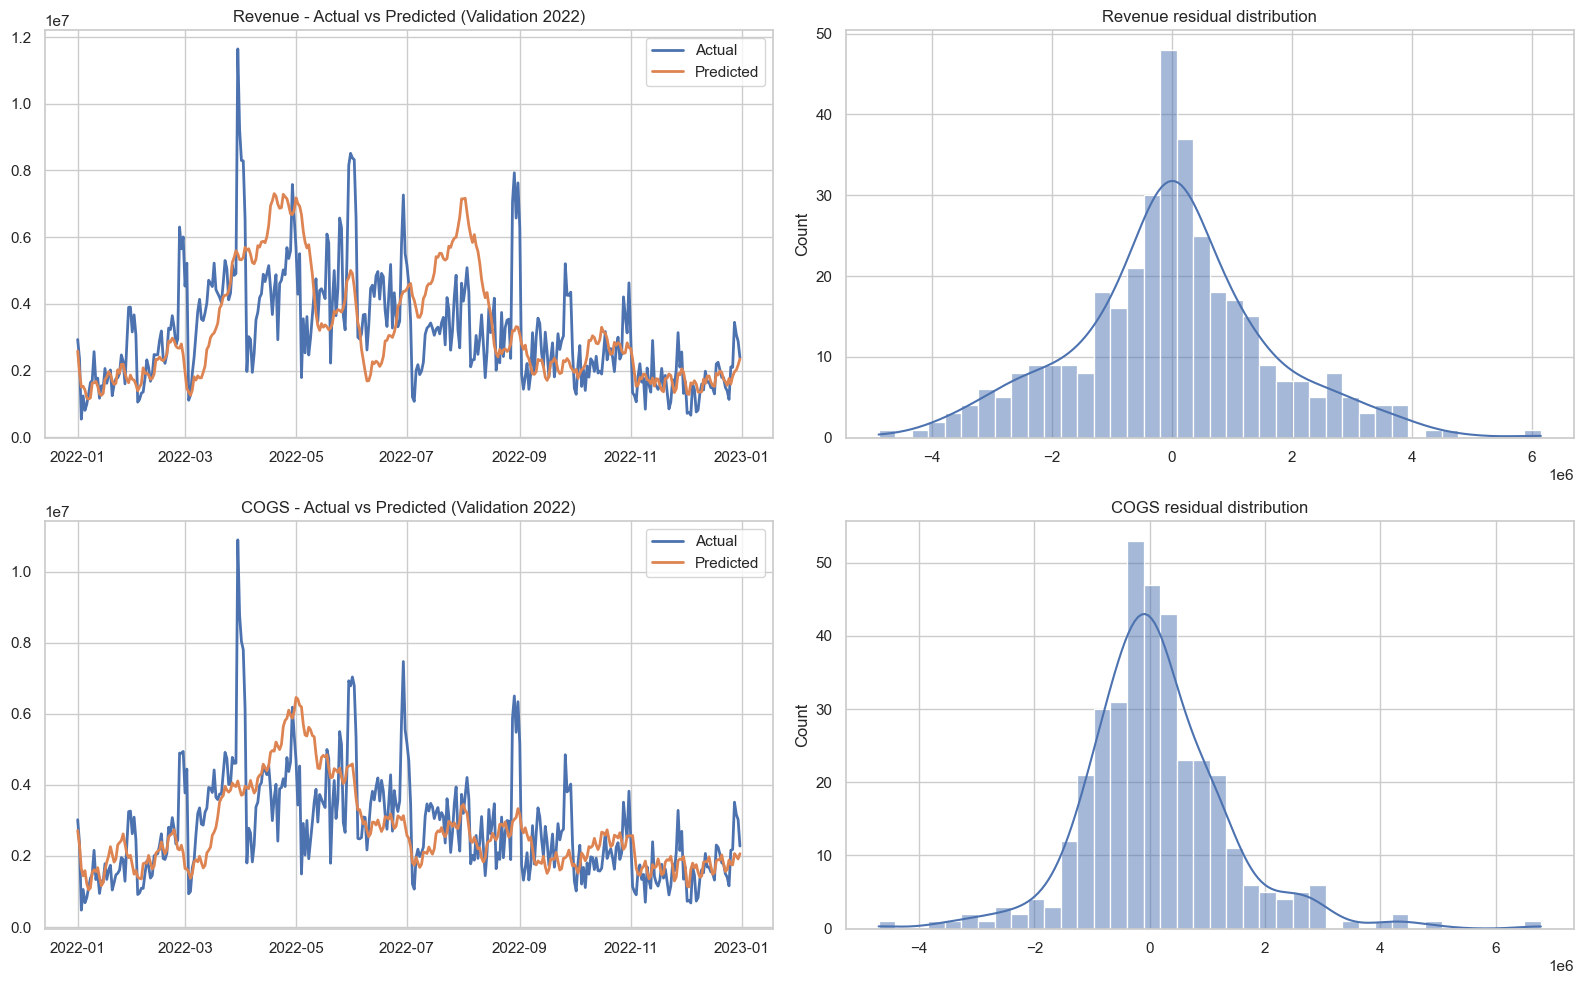

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

axes[0, 0].plot(revenue_result["val_series"].index, revenue_result["val_series"].values, label="Actual", lw=2)
axes[0, 0].plot(revenue_result["val_pred"].index, revenue_result["val_pred"].values, label="Predicted", lw=2)
axes[0, 0].set_title("Revenue - Actual vs Predicted (Validation 2022)")
axes[0, 0].legend()

axes[1, 0].plot(cogs_result["val_series"].index, cogs_result["val_series"].values, label="Actual", lw=2)
axes[1, 0].plot(cogs_result["val_pred"].index, cogs_result["val_pred"].values, label="Predicted", lw=2)
axes[1, 0].set_title("COGS - Actual vs Predicted (Validation 2022)")
axes[1, 0].legend()

rev_res = revenue_result["val_series"] - revenue_result["val_pred"]
cogs_res = cogs_result["val_series"] - cogs_result["val_pred"]

sns.histplot(rev_res, bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Revenue residual distribution")

sns.histplot(cogs_res, bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("COGS residual distribution")

plt.tight_layout()
plt.show()

In [13]:
def fit_full_and_forecast(series, tuned_result, forecast_dates):
    full_train = series.loc[:VAL_END]

    master_dow, master_month, master_global = build_master_priors(VAL_END)
    train_df, target_dow, target_month, target_global = build_training_frame(
        full_train,
        VAL_END,
        master_dow,
        master_month,
        master_global,
    )

    model_pack = fit_models(train_df)

    pred = recursive_predict(
        model_pack=model_pack,
        history_series=full_train.copy(),
        forecast_dates=forecast_dates,
        blend_weight=tuned_result["best_blend"],
        season_alpha=tuned_result["best_season_alpha"],
        target_dow=target_dow,
        target_month=target_month,
        target_global=target_global,
        master_dow=master_dow,
        master_month=master_month,
        master_global=master_global,
        dow_bias=tuned_result["dow_bias"],
        scale=tuned_result["scale"],
    )

    return pred, model_pack


def apply_growth_caps(pred_series, min_factor=0.45, max_factor=2.20):
    out = pred_series.copy().astype(float)
    for i in range(7, len(out)):
        ref = out.iloc[i - 7]
        lower = max(0.0, ref * min_factor)
        upper = max(lower, ref * max_factor)
        out.iloc[i] = float(np.clip(out.iloc[i], lower, upper))
    return out


forecast_dates = pd.DatetimeIndex(sample_submission["Date"])

rev_pred_test, rev_model_full = fit_full_and_forecast(revenue_series, revenue_result, forecast_dates)
cogs_pred_test, cogs_model_full = fit_full_and_forecast(cogs_series, cogs_result, forecast_dates)

# Smooth daily jumps to avoid unrealistic spikes.
rev_pred_test = apply_growth_caps(rev_pred_test, min_factor=0.50, max_factor=2.00)
cogs_pred_test = apply_growth_caps(cogs_pred_test, min_factor=0.50, max_factor=2.00)

# Keep COGS/Revenue ratio inside historical plausible range.
hist_ratio = (sales_full.loc[:VAL_END, "COGS"] / sales_full.loc[:VAL_END, "Revenue"]).replace([np.inf, -np.inf], np.nan).dropna()
ratio_low, ratio_high = hist_ratio.quantile([0.01, 0.995])

ratio_pred = (cogs_pred_test / rev_pred_test).replace([np.inf, -np.inf], np.nan).fillna(hist_ratio.median())
ratio_pred = ratio_pred.clip(lower=float(ratio_low), upper=float(ratio_high))
cogs_pred_test = rev_pred_test * ratio_pred

# Ensure non-negative and COGS <= Revenue.
rev_pred_test = np.clip(rev_pred_test, 0.0, None)
cogs_pred_test = np.clip(cogs_pred_test, 0.0, rev_pred_test * 0.999)

submission = pd.DataFrame(
    {
        "Date": sample_submission["Date"],
        "Revenue": rev_pred_test.values,
        "COGS": cogs_pred_test.values,
    }
)

out_file = OUT_DIR / "sales_submission_v2_optimized.csv"
out_file_main = OUT_DIR / "sales_submission.csv"

submission.to_csv(out_file, index=False)
submission.to_csv(out_file_main, index=False)

val_metrics_file = OUT_DIR / "validation_metrics_v2_optimized.csv"
val_metrics.to_csv(val_metrics_file, index=False)

revenue_result["search_df"].to_csv(OUT_DIR / "revenue_blend_search_v2.csv", index=False)
cogs_result["search_df"].to_csv(OUT_DIR / "cogs_blend_search_v2.csv", index=False)

joblib.dump(rev_model_full, MODEL_DIR / "revenue_recursive_blend_v2.joblib")
joblib.dump(cogs_model_full, MODEL_DIR / "cogs_recursive_blend_v2.joblib")

print("Saved submission:", out_file)
print("Saved main submission:", out_file_main)
print("Saved validation metrics:", val_metrics_file)
submission.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9519
[LightGBM] [Info] Number of data points in the train set: 2949, number of used features: 66
[LightGBM] [Info] Start training from score 15.148664
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9519
[LightGBM] [Info] Number of data points in the train set: 2949, number of used features: 66
[LightGBM] [Info] Start training from score 15.005634
Saved submission: D:\DATATHON-2026-GenApLucUWU\data\output\sales_submission_v2_optimized.csv
Saved main submission: D:\DATATHON-2026-GenApLucUWU\data\output\sales_submission.csv
Saved validation metrics: D:\DATATHON-2026-GenApLucUWU\data\output\validation_metrics_v2_optimized.csv


,Date,Revenue,COGS
0,2023-01-01,2.785959e+06,2.528675e+06
1,2023-01-02,3.798758e+06,3.711321e+06
2,2023-01-03,5.071429e+06,4.775089e+06
3,2023-01-04,6.071037e+06,6.064966e+06
4,2023-01-05,6.692118e+06,6.133254e+06


## Notes

- This notebook is intentionally recursive at validation/test time to match production forecasting conditions.
- If runtime is high, reduce `BLEND_GRID`, `SEASON_GRID`, or tree counts in `LGB_PARAMS` and `XGB_PARAMS`.
- For additional gains, you can run an Optuna search around the chosen model families and keep the same recursive framework.